In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform, beta, binom

In [26]:
def theta_MCMC(p_X__theta, p_theta, proposal="gaussian", sigma=1, num_iter=1000, burn_in_percentage=0.1):
    thetas = [np.clip(np.random.normal(0.5, sigma), 0, 1)]

    while len(thetas) < num_iter:
        theta_new = np.clip(np.random.normal(thetas[-1], sigma), 0, 1)
        if proposal == "uniform": theta_new = np.random.uniform()

        p_theta_new__X = p_X__theta(theta_new) * p_theta(theta_new)
        p_theta__X = p_X__theta(thetas[-1]) * p_theta(thetas[-1])

        q_theta_new__theta = norm.pdf(theta_new, loc=thetas[-1], scale=sigma)
        q_theta__theta_new = norm.pdf(thetas[-1], loc=theta_new, scale=sigma)
        if proposal == "uniform":
            q_theta_new__theta = uniform.pdf(theta_new)
            q_theta__theta_new = uniform.pdf(thetas[-1])

        p_accept = min(1, p_theta_new__X * q_theta__theta_new / p_theta__X / q_theta_new__theta)

        if np.random.uniform() <= p_accept:
            thetas.append(theta_new)

    thetas = thetas[int(num_iter * burn_in_percentage):]

    return thetas

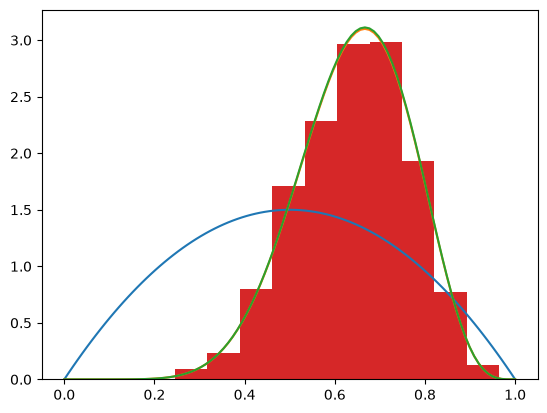

In [29]:
data = 7
pi_beta = np.random.beta(2, 2, 1000)
p_Y = np.mean(binom.pmf(data, 10, pi_beta))


def p_theta__X_simple(pi):
    return binom.pmf(data, 10, pi) * beta.pdf(pi, 2, 2) / p_Y


thetas = np.array(theta_MCMC(p_X__theta=lambda theta: binom.pmf(data, 10, theta), p_theta=lambda theta: beta.pdf(theta, 2, 2), sigma=0.1))

y = np.linspace(0, 1, 100)
plt.plot(y, beta.pdf(y, 2, 2))
plt.plot(y, beta.pdf(y, 9, 5))
plt.plot(y, p_theta__X_simple(y))
plt.hist(thetas, density=True)
plt.show()